In [4]:
# !pip install dendropy
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import squareform
from dendropy.simulate import treesim
from scipy.special import logit, expit
from tqdm import tqdm
from aux_fns import *

from matplotlib import colors as mcolors

set_ggplot_light_theme()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# save_path = "/Users/elenab/Dropbox/work/00_THESIS/figures/cellsnp/"

# Simulate the tree and cluster the cells

In [5]:
V, N, K = 1000, 500, 2

tree = treesim.birth_death_tree(birth_rate=1.0, death_rate=0.5, num_extant_tips=N, rng=random.Random(10))

In [9]:
assignments, linkage_matrix, distances_df = assign_clones_from_tree(tree, K)  # dict: {cell_id:clone_id, ...}
cell_ids = list(assignments.keys())
clone_ids = list(assignments.values())

In [11]:
distances_df.to_csv("../simple_simulated_data/distances.csv")

In [ ]:
# pd.DataFrame(linkage_matrix).to_csv("~/Dropbox/work/00_THESIS/figures/cellsnp/linkage_matrix.csv", index=False)
# pd.DataFrame({"cell_id": cell_ids, "clone_id": clone_ids}).to_csv("~/Dropbox/work/00_THESIS/figures/cellsnp/cell_groups.csv", index=False)

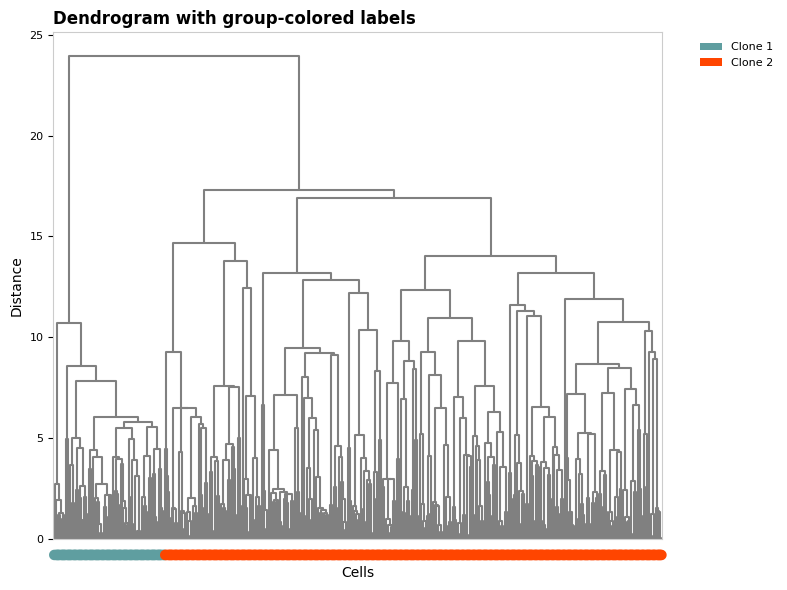

In [12]:
%matplotlib inline
color_list = ["#5F9EA0","#FF4500","#DAA520","#7B68EE"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(set(clone_ids))}
label_colors = [color_map[group] for group in clone_ids]

plot_dendogram(linkage_matrix, cell_ids, clone_ids, color_map)

# Compute the OU kernel

In [13]:
edges = tree_to_edge_list(tree)

In [14]:
kernel = compute_ou_kernel(edges, list(assignments.keys()), lambd=.05, sigma_squared=1.0)
# pd.DataFrame(kernel).to_csv(save_path + "kernel.csv", index=False)

assert kernel.shape[0] == kernel.shape[1]
assert kernel.shape[0] == N

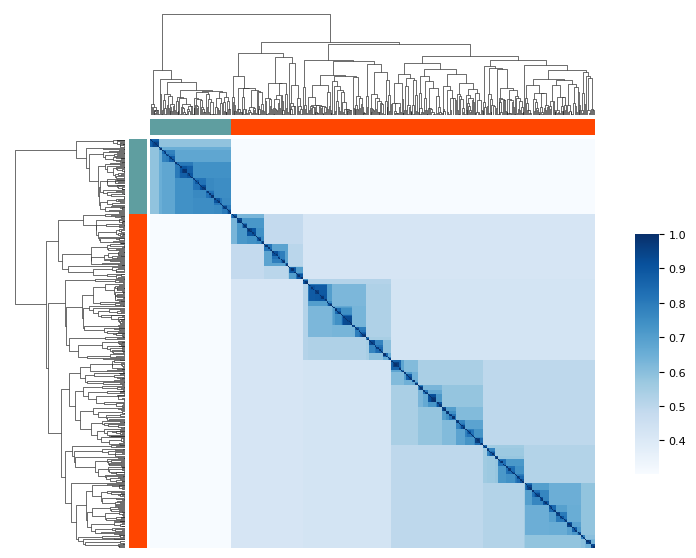

In [15]:
plot_heatmap(kernel, col_colors=label_colors, row_colors=label_colors,
             linkage_matrix_col=linkage_matrix, linkage_matrix_row=linkage_matrix)

# Simulate mu (and theta)

<!-- Here we have 4 clones with phylogeny like this

```
    M
   / \
 C1   /\
     C2 /\
       C3 C4
```

Therefore, we need to simulate
- clonal mutations (shared)
- shared mutations between C2, C3, C4
- shared mutations between C3, C4
- private mutations -->

In [16]:
rng = np.random.default_rng(0)
# 2 clones, 1000 mutations, 500 cells

pi_common = 0.1
p_dropout = 0.5
mean_depth = 10
dispersion = 10

n_trunk = int(pi_common * V)
n_private = (V - n_trunk) // 2

classes = (["trunk"] * n_trunk + ["clone1_private"] * n_private + ["clone2_private"] * (V - n_trunk - n_private))
rng.shuffle(classes)

In [17]:
r = dispersion
p = r / (r + mean_depth)
depths = rng.negative_binomial(r, p, size=(V, N))
drop_mask = rng.random((V, N)) < p_dropout
depths[drop_mask] = 0

u = np.unique(clone_ids)
assert u.size == 2, "Attesi esattamente due cloni in clone_ids"

mask_c1 = (clone_ids == u[0])   # trattiamo u[0] come 'clone1'
mask_c2 = (clone_ids == u[1])   # trattiamo u[1] come 'clone2'

classes = np.asarray(classes)

G = np.zeros((V, N), dtype=np.int8)
G[classes == "trunk", :]           = 1
G[classes == "clone1_private", :]  = mask_c1  # broadcast sul numero di righe selezionate
G[classes == "clone2_private", :]  = mask_c2

alt_counts = np.zeros_like(depths)
mask_mut = (G == 1) & (depths > 0)
alt_counts[mask_mut] = rng.binomial(depths[mask_mut], 0.5)

# Simulate gamma and sample observed variables

In [18]:
# DP_true = np.full((V,N), 100) + np.round(np.random.normal(0, 1, size=(V,N))).astype(int)
# AD_true = np.random.binomial(DP_true, theta_true)

DP = pd.DataFrame(depths)
AD = pd.DataFrame(alt_counts)
theta_t = (AD/DP).fillna(0)
theta_t[theta_t==0] = 1e-15
theta_t[theta_t==1] = 1. - 1e-15

gamma_t = mu_t = logit(theta_t)

In [19]:
data_true = pd.concat([array_to_df(theta_t, "VAF", cell_ids), \
                       array_to_df(AD, "AD", cell_ids)["AD"], \
                       array_to_df(DP, "DP", cell_ids)["DP"], \
                       array_to_df(gamma_t, "gamma", cell_ids)["gamma"]], \
                       axis=1, join="inner")
data_true["clone_ids"] = [str(assignments[i]) for i in data_true["cell_ids"]]
# data_true.to_csv(out_folder+"data_true.csv")
data_true.head()

,mutation_ids,cell_ids,VAF,AD,DP,gamma,clone_ids
0,0,T489,1.000000e-15,0,0,-34.538776,2
1,1,T489,1.000000e-15,0,0,-34.538776,2
2,2,T489,1.000000e-15,0,4,-34.538776,2
3,3,T489,1.000000e-15,0,0,-34.538776,2
4,4,T489,4.705882e-01,8,17,-0.117783,2


/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


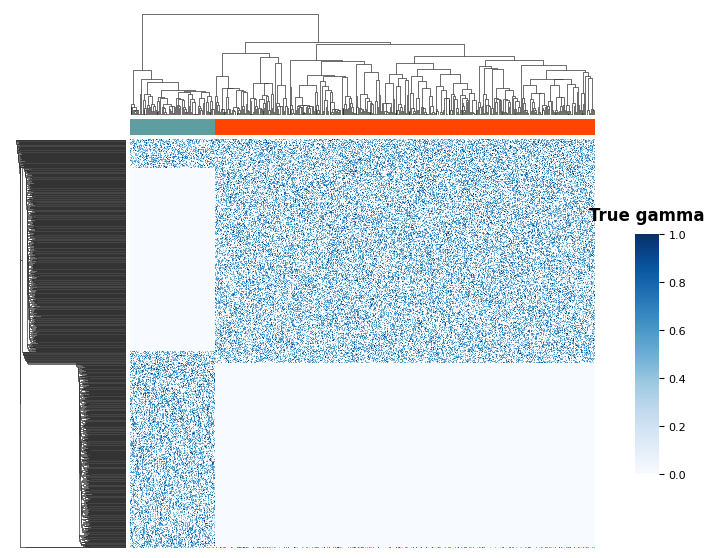

In [20]:
plot_heatmap(theta_t, col_colors=label_colors, linkage_matrix_col=linkage_matrix,
            legend_title="True gamma")

In [ ]:
linkage_matrix

# Run the model

In [ ]:
import torch
import time
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.autograd.functional import hessian
%load_ext autoreload
%autoreload 2

In [ ]:
# device = torch.device("cuda")
# device = torch.device("mps")
device = torch.device("cpu")

In [ ]:
# convert to tensor the data
Y = torch.tensor(AD_true).to(device=device)
D = torch.tensor(DP_true).to(device=device)
Z = torch.tensor(clone_ids, dtype=torch.int, device=device)

V, N = Y.shape  # #mutations x #cells
K = len(Z.unique())  # #clones

learning_rate = 0.005

assert Y.shape[1] == D.shape[1]
assert Y.shape[1] == Z.shape[0]
print(f"{V} SNPs, {N} cells and {K} clones\n")

print(f"Devices\nY = {Y.device}\nD = {D.device}\nZ = {Z.device}")

Initialize the parameters and optimizer, and run the inference

In [ ]:
# Initialize mu
mu_init = logit_clipped(Y/D)  # initialize mu as a sampling from a beta(1,1)
mu = mu_init.detach().clone().requires_grad_(True)

# Initialize gamma
# gamma_hat_init = logit_clipped(Y/D) + torch.normal(mean=torch.zeros_like(Y, dtype=torch.float32), std=torch.ones_like(Y, dtype=torch.float32))
gamma_hat_init = torch.randn_like(mu)
gamma_hat = mu_init.detach().clone().requires_grad_(False)

# Initialize the covariance matrix
Sigma = torch.tensor(kernel, dtype=torch.float32, device=device) + 1e-6*torch.eye(N, device=device)
Sigma_inv = torch.linalg.inv(Sigma)  # inverese of Sigma -> N x N
log_det_Sigma = torch.logdet(Sigma)  # log of determinant of Sigma

# Check the device of all parameters
print(f"Devices\nmu = {mu.device}\nSigma = {Sigma.device}\nSigma_inv = {Sigma_inv.device}\nlog_det_Sigma = {log_det_Sigma.device}\ngamma_hat = {gamma_hat.device}")

# Optimizer
optimizer = optim.Adam([mu], lr=learning_rate)

# Store initial time and lists
start_time = time.time()
losses, gradients = [], []

from functorch import vmap
compute_laplace_term_batched = vmap(compute_laplace_term, in_dims=(0,0,0,None,0))

# Start the inference
pbar = tqdm(range(50))
for _ in pbar:

    # optimizer.zero_grad()
    # laplace_terms, gamma_hat[:] = compute_laplace_term_batched(Y, D, mu, Sigma_inv, gamma_hat)
    # loss = -laplace_terms.sum()
    # loss.backward()
    # optimizer.step()

    optimizer.zero_grad()  # reset the gradient
    total_laplace = 0.0
    for v in range(V):
        # compute log p(y_v | d_v, mu_v, Sigma) with laplace approx
        y_v = Y[v, :]
        d_v = D[v, :]
        laplace_term, gamma_hat_v = compute_laplace_term(y_v, d_v, mu[v,:], Sigma_inv, gamma_hat[v,:])
        total_laplace += laplace_term
        gamma_hat[v,:] = gamma_hat_v

    loss = -total_laplace
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    gradients.append(mu.grad.norm().item())

    pbar.set_description(f"Loss = {loss.item()}")

# Store final time
end_time = time.time()

# Evaluation

In [ ]:
plt.plot(losses)
# plt.plot(gradients)

In [ ]:
mu_np = mu.cpu().detach().numpy()
# pl1 = sns.clustermap(mu_np, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
# pl1 = pl1.fig.suptitle("Inferred mu")

# pl2 = sns.clustermap(mu_init.cpu(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 8))
# pl2 = pl2.fig.suptitle("Initial mu")

pl1 = sns.clustermap(np.abs(expit(mu_init.cpu().numpy()) - expit(mu_np)),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0., vmax=0.5,
                     figsize=(5, 5))
pl1 = pl1.fig.suptitle("Initial mu - Inferred mu")

pl3 = sns.clustermap(np.abs(expit(mu_true) - expit(mu_np)),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0., vmax=0.5,
                     figsize=(5, 5))
pl3 = pl3.fig.suptitle("True mu - Inferred mu")

In [ ]:
df = pd.DataFrame({"mu_true": mu_true.flatten(), "mu_inferred": mu_np.flatten()})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="mu_true", y="mu_inferred", alpha=0.6, s=50, edgecolor="w")
min_val = min(np.min(df.mu_true), np.min(df.mu_inferred))
max_val = max(np.max(df.mu_true), np.max(df.mu_inferred))
plt.plot([min_val, max_val], [min_val, max_val], "r--")

In [ ]:
pl1 = sns.clustermap(np.abs(expit(gamma_hat_init.cpu().numpy()) - expit(gamma_hat.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl1 = pl1.fig.suptitle("Abs diff of initial and optimized gamma in the prob space")

pl2 = sns.clustermap(np.abs(expit(gamma_true) - expit(gamma_hat.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl2 = pl2.fig.suptitle("Abs diff of true and optimized gamma in the prob space")

pl3 = sns.clustermap(np.abs(expit(gamma_true) - expit(gamma_hat_init.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl3 = pl3.fig.suptitle("Abs diff of true and initial gamma in the prob space")
# pl2 = sns.clustermap(gamma_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
# pl2 = pl2.fig.suptitle("True gamma")

In [ ]:
sns.clustermap(gamma_hat_init.cpu().numpy(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
sns.clustermap(gamma_hat.cpu().numpy(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
sns.clustermap(gamma_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))

In [ ]:
end_time - start_time